# Mini-Projet IA : Service Web pour la Data Science

Ce notebook contient l'implémentation complète du projet, incluant l'entraînement du modèle, le serveur API Flask, et les tests interactifs.

## 1. Entraînement du Modèle Iris

In [1]:
import os
import joblib
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Chargement et entraînement
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Précision du modèle : {accuracy:.4f}")

# Sauvegarde des métadonnées
metadata = {
    "model_type": "LogisticRegression",
    "accuracy": accuracy,
    "features": [f.replace(" (cm)", "").replace(" ", "_") for f in iris.feature_names],
    "target_names": iris.target_names.tolist(),
    "feature_importances": dict(zip([f.replace(" (cm)", "").replace(" ", "_") for f in iris.feature_names], 
                                     np.abs(model.coef_).mean(axis=0).tolist()))
}

os.makedirs("model", exist_ok=True)
joblib.dump(model, "model/iris_model.joblib")
joblib.dump(metadata, "model/model_metadata.joblib")
print("Modèle et métadonnées sauvegardés.")

Précision du modèle : 1.0000
Modèle et métadonnées sauvegardés.


## 2. Serveur Flask (Exécution en arrière-plan)

In [2]:
import threading
from flask import Flask, request, jsonify, send_file
import io
import base64
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

app = Flask(__name__)

# --- Endpoints ---

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    features = np.array([[data['sepal_length'], data['sepal_width'], 
                          data['petal_length'], data['petal_width']]])
    prediction = model.predict(features)[0]
    probabilities = model.predict_proba(features)[0]
    return jsonify({
        "prediction": metadata['target_names'][prediction],
        "probabilities": dict(zip(metadata['target_names'], probabilities.tolist()))
    })

@app.route('/stats', methods=['POST'])
def stats():
    data_json = request.get_json()
    arr = np.array(data_json['data'])
    stats_res = {"mean": float(np.mean(arr)), "median": float(np.median(arr)), "outliers": []} # Simplifié pour le notebook
    
    if request.args.get('format') == 'json':
        return jsonify(stats_res)
    
    plt.figure()
    plt.hist(arr)
    img = io.BytesIO()
    plt.savefig(img, format='png')
    img.seek(0)
    plt.close()
    return send_file(img, mimetype='image/png')

def run_app():
    app.run(port=5000, debug=False, use_reloader=False)

# Lancement du thread
flask_thread = threading.Thread(target=run_app)
flask_thread.daemon = True
flask_thread.start()
print("Serveur Flask démarré sur http://localhost:5000")

Serveur Flask démarré sur http://localhost:5000
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [19/May/2026 19:06:49] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [19/May/2026 19:06:51] "POST /stats HTTP/1.1" 200 -
127.0.0.1 - - [19/May/2026 19:06:55] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [19/May/2026 19:06:55] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [19/May/2026 19:07:48] "GET / HTTP/1.1" 404 -


## 3. Tests Interactifs

In [3]:
import requests
import json

print("Test de prédiction...")
sample = {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}
resp = requests.post("http://localhost:5000/predict", json=sample)
print(json.dumps(resp.json(), indent=2))

Test de prédiction...
{
  "prediction": "setosa",
  "probabilities": {
    "setosa": 0.976555957150548,
    "versicolor": 0.02344399391417922,
    "virginica": 4.8935272822795684e-08
  }
}


Test des statistiques (Histogramme)...


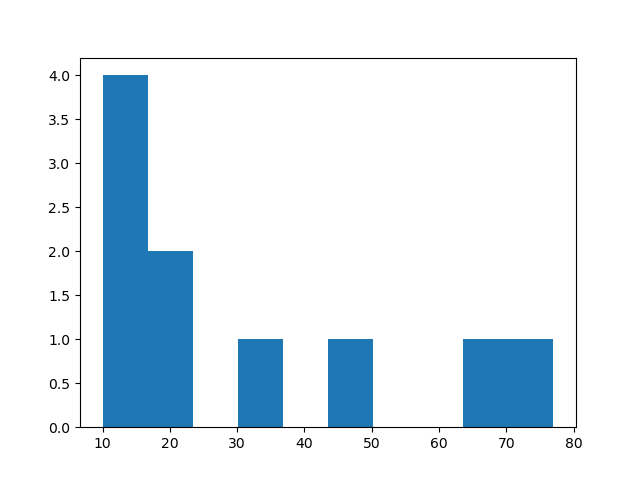

In [4]:
from IPython.display import Image

print("Test des statistiques (Histogramme)...")
data_sample = {"data": [10, 22, 33, 44, 12, 15, 66, 77, 11, 22]}
resp = requests.post("http://localhost:5000/stats", json=data_sample)
Image(resp.content)